In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from models.SCS import StochasticConjugateSubgradientAlgorithm


In [6]:
def generate_nested_circles(n_samples=500, noise=0.04):
        half_samples = n_samples // 2

        # Outer Ring (Class +1)
        theta_out = np.linspace(0, 2 * np.pi, half_samples, endpoint=False)
        X_out = np.vstack([2*np.cos(theta_out), 2*np.sin(theta_out)]).T

        # Inner Ring (Class -1)
        theta_in = np.linspace(0, 2 * np.pi, half_samples, endpoint=False)
        X_in = np.vstack([0.4 * np.cos(theta_in), 0.4 * np.sin(theta_in)]).T

        X = np.vstack([X_out, X_in])
        X += np.random.normal(scale=noise, size=X.shape)  # Add normal scatter variance
        y = np.hstack([np.ones(half_samples), -np.ones(half_samples)])
        return X, y

In [97]:
X, y = generate_nested_circles(n_samples=5000, noise=0.03)
shuffle_idx = np.arange(len(X))
np.random.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
model = StochasticConjugateSubgradientAlgorithm(gamma_rbf=3, verbose=True)

print("\nStarting SCS Optimization loop training process...")
model.fit(X_train, y_train, max_iter=1000, batch_size=1)


Starting SCS Optimization loop training process...
Insufficient samples remaining to construct validation batch T_k.



Starting SCS Optimization loop training process...
Insufficient samples remaining to construct validation batch T_k.


In [96]:
np.mean(model.predict(X_test)==y_test)

np.float64(0.771)

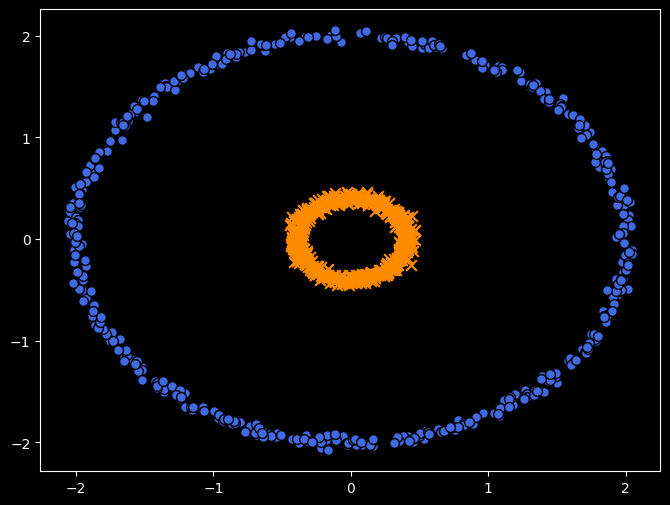

In [20]:
y_pred=model.predict(X_test)
class_plus = X_test[y_pred == 1]
class_minus = X_test[y_pred == -1]

# Create the figure
plt.figure(figsize=(8, 6))

# Plot Class +1 (e.g., as blue circles)
plt.scatter(
    class_plus[:, 0],
    class_plus[:, 1],
    color='royalblue',
    marker='o',
    edgecolors='k',
    s=50,
    label='Class +1'
)

# Plot Class -1 (e.g., as orange crosses)
plt.scatter(
    class_minus[:, 0],
    class_minus[:, 1],
    color='darkorange',
    marker='x',
    s=60,
    label='Class -1'
)

In [21]:
np.mean(y_pred==y_test)

np.float64(1.0)